# Fake News Detection Using Machine Learning
**Dataset:** ISOT Fake News Dataset (True.csv + Fake.csv)  
**Deployment Target:** Flask API (CPU-optimised)

---
## Group Details
| Name | CPM | MC |
| -- | -- | -- |
| Minoli Perera | 24375 | 108853 |
| Sandagomi Kodikara | 24377 | 108852 |
| Savindi Dissanayake | 24381 | 108798 |

---
## Table of Contents
1. Install & Import Libraries
2. Load Data & Add Labels
3. Exploratory Data Analysis (EDA)
4. Text Preprocessing
5. Train / Validation / Test Split (80/10/10)
6. TF-IDF Feature Extraction
7. Model Training
8. Evaluation, Confusion Matrices & ROC Curves
9. Cross-Validation
10. Ablation Study
11. Export Best Model for Flask

---
## Step 1: Install & Import Libraries

In [ ]:
# Install required packages (run once)
# ! pip install lightgbm xgboost wordcloud nltk scikit-learn pandas numpy matplotlib seaborn joblib kagglehub tensorflow

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re, string, time, joblib, json, os, warnings
warnings.filterwarnings('ignore')

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('omw-1.4',   quiet=True)

# Feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import chi2

# Models
from sklearn.linear_model    import LogisticRegression
from sklearn.svm             import LinearSVC
from sklearn.naive_bayes     import MultinomialNB
from sklearn.ensemble        import RandomForestClassifier
from sklearn.calibration     import CalibratedClassifierCV
import xgboost as xgb

# Evaluation
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, ConfusionMatrixDisplay
)

# Word cloud
from wordcloud import WordCloud

# Deep learning
import tensorflow as tf
from tensorflow.keras.models              import Sequential
from tensorflow.keras.layers             import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Plot style
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
PALETTE = ['#e74c3c', '#2ecc71']   # red = Fake, green = Real

print('All libraries imported successfully ✓')

All libraries imported successfully ✓


---
## Step 2: Load Data & Add Labels

In [ ]:
import kagglehub

# Download dataset from Kaggle
path = kagglehub.dataset_download('clmentbisaillon/fake-and-real-news-dataset')

print('Loading datasets...')
true_df = pd.read_csv(f'{path}/True.csv')
fake_df = pd.read_csv(f'{path}/Fake.csv')

true_df['label'] = 1   # 1 = Real
fake_df['label'] = 0   # 0 = Fake

news_df = pd.concat([true_df, fake_df], axis=0)
news_df = news_df.sample(frac=1, random_state=42).reset_index(drop=True)  

print(f'Total rows    : {len(news_df):,}')
print(f'Columns       : {list(news_df.columns)}')
print(f'\nClass distribution (0=Fake, 1=Real):')
print(news_df['label'].value_counts())
news_df.head(3)

Using Colab cache for faster access to the 'fake-and-real-news-dataset' dataset.
Loading datasets...
Total rows    : 44,898
Columns       : ['title', 'text', 'subject', 'date', 'label']

Class distribution (0=Fake, 1=Real):
label
0    23481
1    21417
Name: count, dtype: int64


,title,text,subject,date,label
0,BREAKING: GOP Chairman Grassley Has Had Enoug...,"Donald Trump s White House is in chaos, and th...",News,"July 21, 2017",0
1,Failed GOP Candidates Remembered In Hilarious...,Now that Donald Trump is the presumptive GOP n...,News,"May 7, 2016",0
2,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,Mike Pence is a huge homophobe. He supports ex...,News,"December 3, 2016",0


---
## Step 3: Exploratory Data Analysis (EDA)
### 3a. Class Distribution

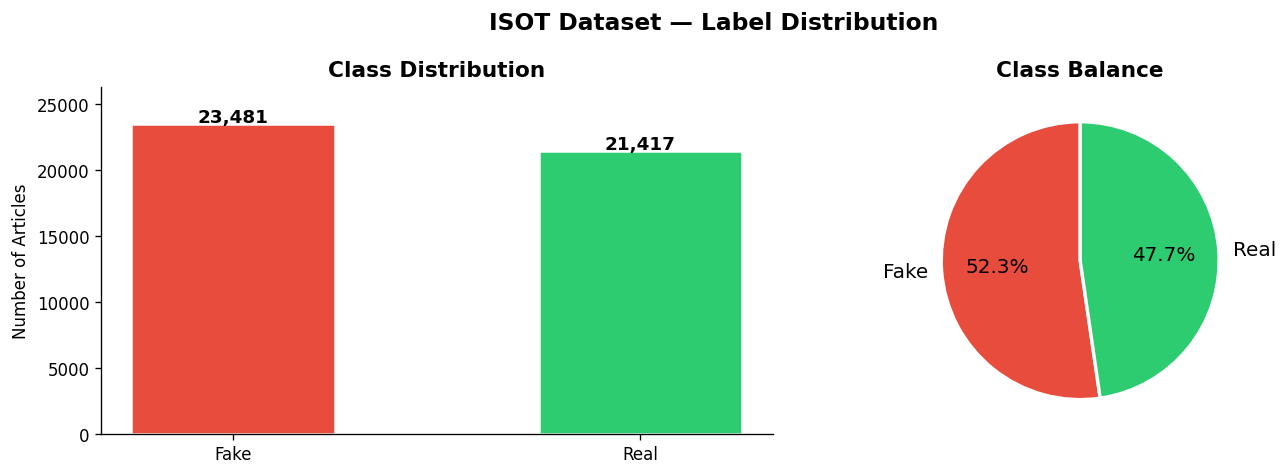

Mild imbalance (~52% Fake / ~48% Real) — manageable with stratified splits.


In [4]:
counts = news_df['label'].value_counts().sort_index()  # [Fake, Real]
labels = ['Fake', 'Real']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(labels, counts.values, color=PALETTE, edgecolor='white', linewidth=1.5, width=0.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 150, f'{v:,}', ha='center', fontweight='bold', fontsize=11)
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Articles')
axes[0].set_ylim(0, max(counts.values) * 1.12)

# Pie chart
axes[1].pie(counts.values, labels=labels, colors=PALETTE,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2},
            textprops={'fontsize': 12})
axes[1].set_title('Class Balance', fontsize=13, fontweight='bold')

plt.suptitle('ISOT Dataset — Label Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('Mild imbalance (~52% Fake / ~48% Real) — manageable with stratified splits.')

### 3b. Article Length Distribution

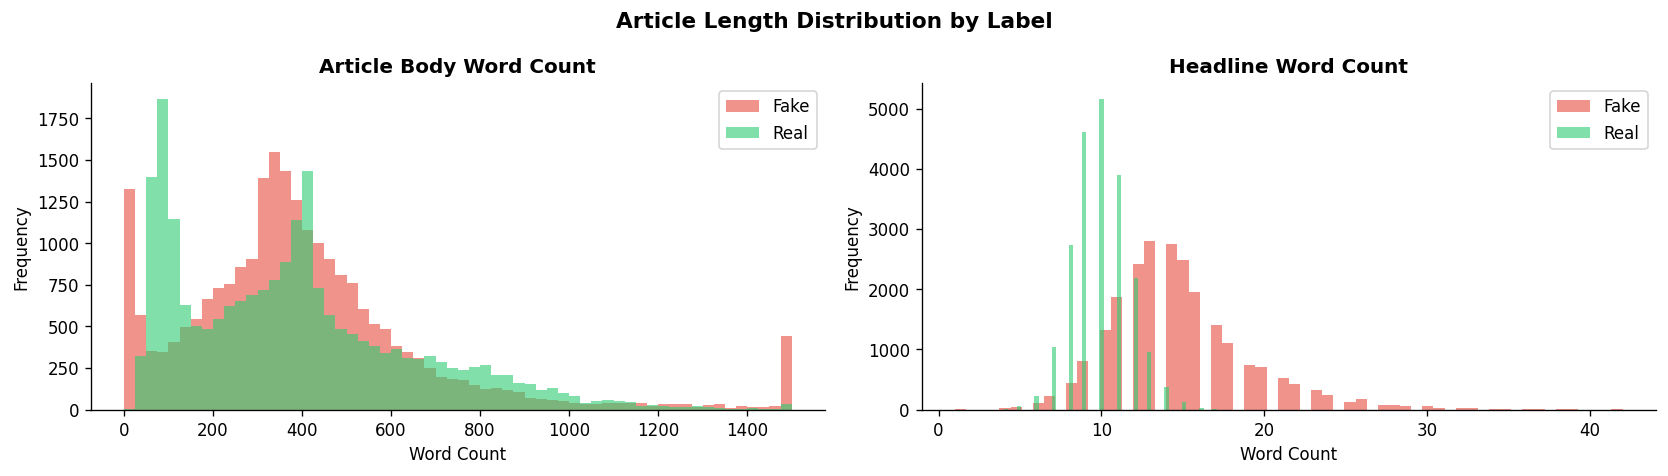


Body length statistics by label:
         count   mean    std  min    25%    50%    75%     max
label                                                         
Fake   23481.0  423.2  408.4  0.0  240.0  363.0  506.0  8135.0
Real   21417.0  385.6  274.0  0.0  148.0  359.0  525.0  5172.0


In [5]:
news_df['text_len']  = news_df['text'].str.split().str.len()
news_df['title_len'] = news_df['title'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for i, (col, title) in enumerate([('text_len',  'Article Body Word Count'),
                                    ('title_len', 'Headline Word Count')]):
    for label_val, color, name in zip([0, 1], PALETTE, ['Fake', 'Real']):
        axes[i].hist(
            news_df[news_df['label'] == label_val][col].clip(upper=1500),
            bins=60, alpha=0.6, color=color, label=name, edgecolor='none')
    axes[i].set_title(title, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Word Count')
    axes[i].set_ylabel('Frequency')
    axes[i].legend()

plt.suptitle('Article Length Distribution by Label', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nBody length statistics by label:')
print(news_df.groupby('label')['text_len'].describe()
      .round(1).rename(index={0: 'Fake', 1: 'Real'}))

### 3c. Subject Category Distribution

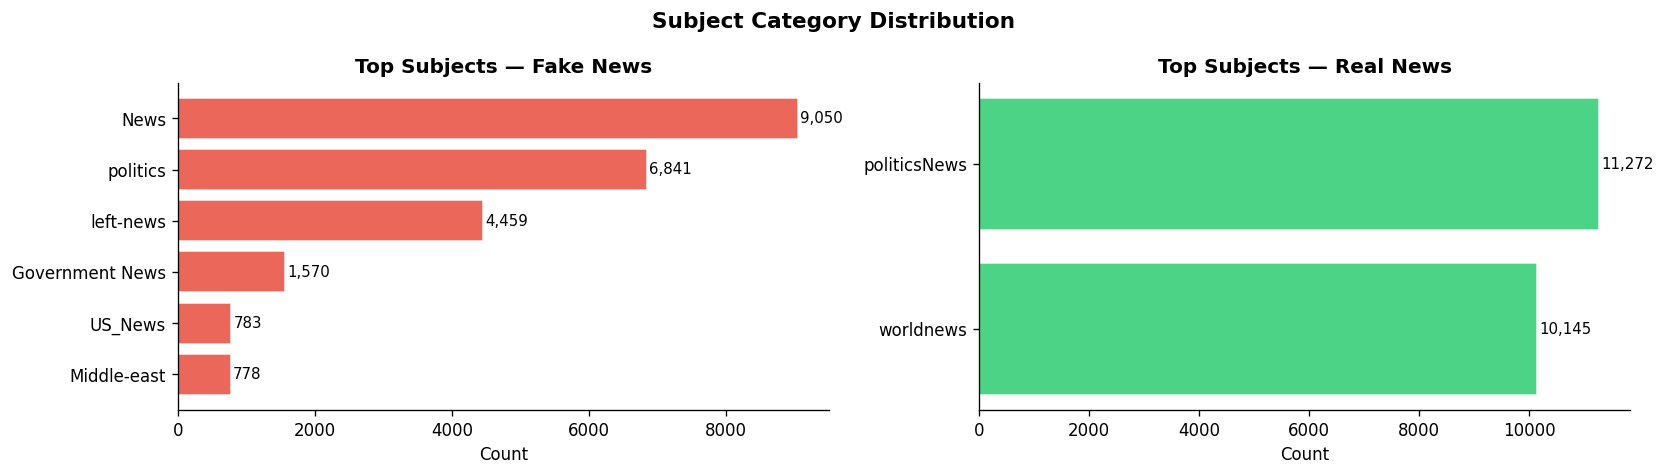

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (label_val, title, color) in zip(
        axes, [(0, 'Fake News', '#e74c3c'), (1, 'Real News', '#2ecc71')]):
    cnts = news_df[news_df['label'] == label_val]['subject'].value_counts().head(8)
    ax.barh(cnts.index[::-1], cnts.values[::-1], color=color, alpha=0.85, edgecolor='white')
    ax.set_title(f'Top Subjects — {title}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Count')
    for i, v in enumerate(cnts.values[::-1]):
        ax.text(v + 30, i, f'{v:,}', va='center', fontsize=9)

plt.suptitle('Subject Category Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 3d. Word Clouds

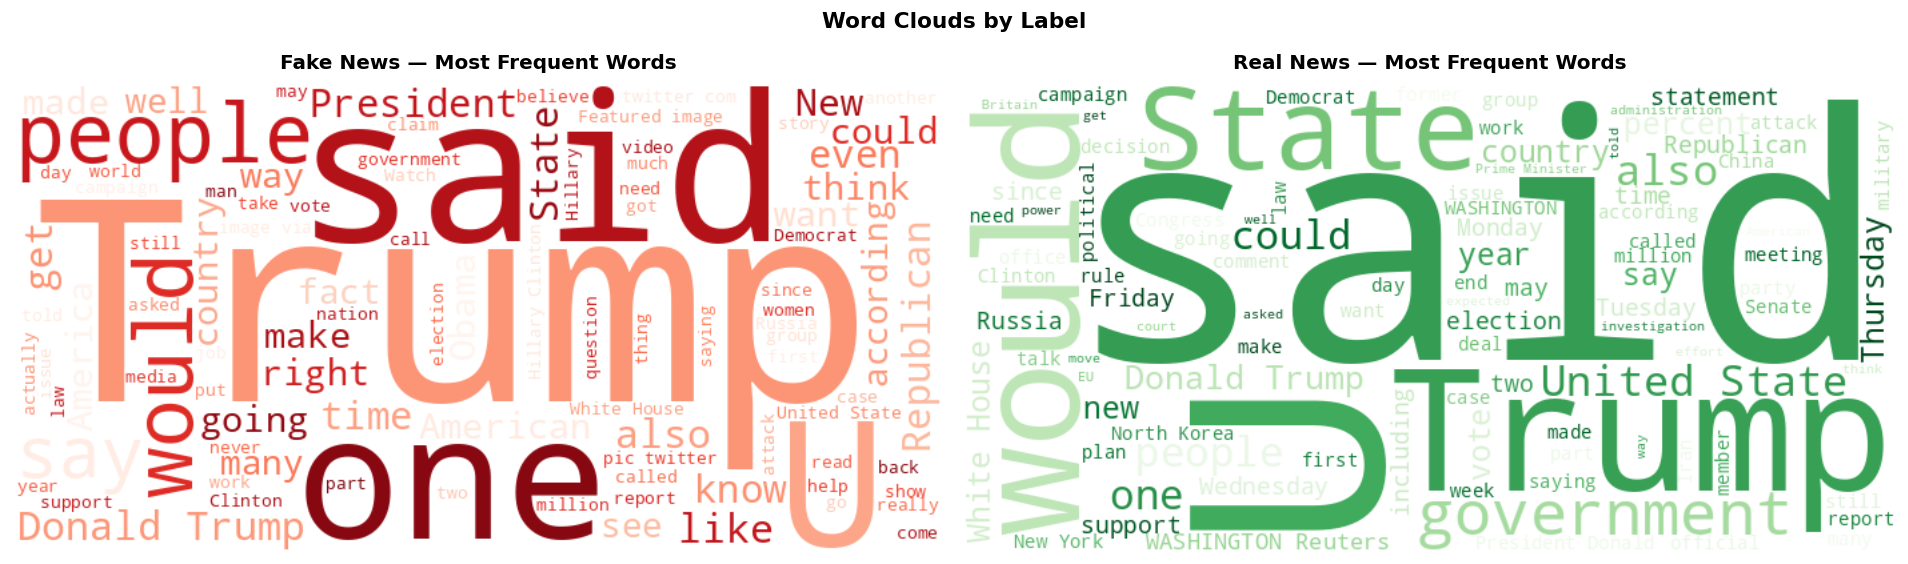

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sw = set(stopwords.words('english'))

for ax, (label_val, title, cmap) in zip(axes, [
        (0, 'Fake News — Most Frequent Words', 'Reds'),
        (1, 'Real News — Most Frequent Words', 'Greens')]):
    sample_size = min(3000, (news_df['label'] == label_val).sum())
    text = ' '.join(
        news_df[news_df['label'] == label_val]['text']
        .dropna().sample(sample_size, random_state=42)
    )
    wc = WordCloud(width=700, height=350, background_color='white',
                   max_words=100, colormap=cmap, stopwords=sw).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)

plt.suptitle('Word Clouds by Label', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 4: Text Preprocessing
> **FIX applied:** Added lemmatization. Reuters dateline stripping retained to prevent data leakage.

In [8]:
lemmatizer = WordNetLemmatizer()
stop_words  = set(stopwords.words('english'))

def clean_text(text: str) -> str:
    text = str(text).lower()

    # ── Data-leakage fix ───────────────────────────────────────────────────────
    # Real articles often start with "CITY (Reuters) -"; remove this source tag
    # so the model learns content patterns, not publisher identity.
    text = re.sub(r'\(reuters\)\s*-\s*', '', text)
    text = re.sub(r'\breuters\b', '', text)
    # ──────────────────────────────────────────────────────────────────────────

    text = re.sub(r'https?://\S+|www\.\S+', '', text)          # Remove URLs
    text = re.sub(r'<.*?>', '', text)                            # Remove HTML
    text = re.sub(r"won't", 'will not', text)                   # Expand contractions
    text = re.sub(r"can't", 'cannot', text)
    text = re.sub(r"n't",   ' not', text)
    text = re.sub(r"'re",   ' are', text)
    text = re.sub(r"'ve",   ' have', text)
    text = re.sub(r"'ll",   ' will', text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), ' ', text)  # Remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()                    # Normalise whitespace

    # Tokenise → remove stopwords → lemmatize  ← NEW
    tokens = [
        lemmatizer.lemmatize(w)
        for w in text.split()
        if w not in stop_words and len(w) > 2
    ]
    return ' '.join(tokens)

# Combine title + text for richer signal, then clean
print('Combining title + text and applying preprocessing...')
print('(This takes ~1-2 minutes on Colab)')
t0 = time.time()

news_df['full_text']  = news_df['title'] + ' ' + news_df['text']
news_df['clean_text'] = news_df['full_text'].apply(clean_text)

print(f'Done in {time.time()-t0:.1f}s ✓')
print(f'\nSample before: {news_df["full_text"].iloc[0][:120]}')
print(f'Sample after : {news_df["clean_text"].iloc[0][:120]}')

Combining title + text and applying preprocessing...
(This takes ~1-2 minutes on Colab)
Done in 81.0s ✓

Sample before:  BREAKING: GOP Chairman Grassley Has Had Enough, DEMANDS Trump Jr. Testimony Donald Trump s White House is in chaos, and
Sample after : breaking gop chairman grassley enough demand trump testimony donald trump white house chaos trying cover russia problem 


---
## Step 5: Train / Validation / Test Split (80 / 10 / 10)
> **FIX applied:** Changed from a single 70/30 split to the 80/10/10 split specified in the proposal.
> The vectorizer is fitted **only on the training set** to prevent data leakage.

In [9]:
X = news_df['clean_text']
y = news_df['label']

# Step 1: split off 20% as temp set
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42)

# Step 2: split temp equally into val and test (10% each)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

print(f'Train : {len(X_train):,} samples  ({len(X_train)/len(X)*100:.1f}%)')
print(f'Val   : {len(X_val):,}  samples  ({len(X_val)/len(X)*100:.1f}%)')
print(f'Test  : {len(X_test):,}  samples  ({len(X_test)/len(X)*100:.1f}%)')
print(f'\nClass balance in train — Fake: {sum(y_train==0):,}  Real: {sum(y_train==1):,}')

Train : 35,918 samples  (80.0%)
Val   : 4,490  samples  (10.0%)
Test  : 4,490  samples  (10.0%)

Class balance in train — Fake: 18,785  Real: 17,133


---
## Step 6: TF-IDF Feature Extraction
> **FIX applied:** `max_features` raised from 10,000 → 50,000 for better coverage of the vocabulary.

Fitting TF-IDF on training data only...
Done in 58.5s ✓
Vocabulary size : 50,000
Train matrix    : (35918, 50000)


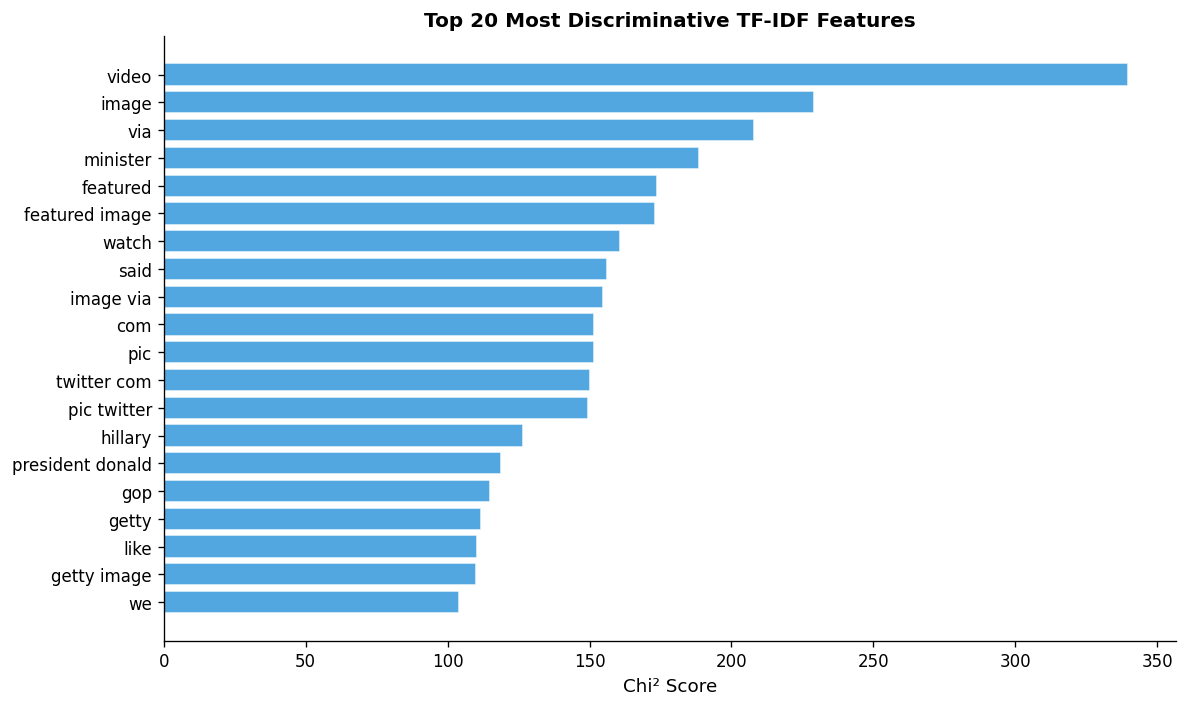

In [ ]:
# Fit ONLY on training data — never on val/test
tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),     # unigrams + bigrams
    max_features=50_000,    # FIX: raised from 10k for better vocab coverage
    sublinear_tf=True,      # log(1+tf) dampens very frequent terms
    min_df=3,               # ignore terms that appear in < 3 docs
    max_df=0.90,            # ignore terms in > 90% of docs
    strip_accents='unicode' # normalize accents for better matching (e.g. café → cafe)
)

print('Fitting TF-IDF on training data only...')
t0 = time.time()
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)   # fit + transform
X_val_tfidf   = tfidf_vectorizer.transform(X_val)         # transform only
X_test_tfidf  = tfidf_vectorizer.transform(X_test)        # transform only

print(f'Done in {time.time()-t0:.1f}s ✓')
print(f'Vocabulary size : {len(tfidf_vectorizer.vocabulary_):,}')
print(f'Train matrix    : {X_train_tfidf.shape}')

# Top discriminative features
chi2_scores, _ = chi2(X_train_tfidf, y_train)
feat_names     = tfidf_vectorizer.get_feature_names_out()
top_idx        = np.argsort(chi2_scores)[::-1][:20]
top_feats      = [(feat_names[i], chi2_scores[i]) for i in top_idx]

fig, ax = plt.subplots(figsize=(10, 6))
names, scores = zip(*top_feats[::-1])
ax.barh(names, scores, color='#3498db', alpha=0.85, edgecolor='white')
ax.set_xlabel('Chi² Score', fontsize=11)
ax.set_title('Top 20 Most Discriminative TF-IDF Features', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 7: Model Training

In [ ]:
# Shared evaluation helper
def evaluate(model, X_vec, y_true):
    y_pred = model.predict(X_vec)
    y_prob = (
        model.predict_proba(X_vec)[:, 1]
        if hasattr(model, 'predict_proba')
        else model.decision_function(X_vec)
    )
    return {
        'Accuracy' : accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average='macro'),
        'Recall'   : recall_score(y_true, y_pred, average='macro'),
        'F1 (macro)': f1_score(y_true, y_pred, average='macro'),
        'ROC-AUC'  : roc_auc_score(y_true, y_prob),
        'y_pred'   : y_pred,
        'y_prob'   : y_prob,
    }

val_results = {}
model_store = {} # This is used to save fitted models for later use in the app (e.g. for test set evaluation and final deployment)
print('Helpers ready ✓')

Helpers ready ✓


### 7a. Logistic Regression

In [ ]:
print('Training Logistic Regression...')
t0 = time.time()
log_model = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
log_model.fit(X_train_tfidf, y_train)
train_time = time.time() - t0

val_results['Logistic Regression'] = evaluate(log_model, X_val_tfidf, y_val)
val_results['Logistic Regression']['train_time'] = train_time
model_store['Logistic Regression'] = log_model

print(f'  Done in {train_time:.1f}s')
print(f'  Val Accuracy : {val_results["Logistic Regression"]["Accuracy"]:.4f}')
print(f'  Val F1-macro : {val_results["Logistic Regression"]["F1 (macro)"]:.4f}')
print(f'  Val ROC-AUC  : {val_results["Logistic Regression"]["ROC-AUC"]:.4f}')

Training Logistic Regression...
  Done in 2.9s
  Val Accuracy : 0.9886
  Val F1-macro : 0.9886
  Val ROC-AUC  : 0.9990


### 7b. Naive Bayes

In [13]:
print('Training Naive Bayes...')
t0 = time.time()
nb_model = MultinomialNB(alpha=0.1)
nb_model.fit(X_train_tfidf, y_train)
train_time = time.time() - t0

val_results['Naive Bayes'] = evaluate(nb_model, X_val_tfidf, y_val)
val_results['Naive Bayes']['train_time'] = train_time
model_store['Naive Bayes'] = nb_model

print(f'  Done in {train_time:.1f}s')
print(f'  Val Accuracy : {val_results["Naive Bayes"]["Accuracy"]:.4f}')
print(f'  Val F1-macro : {val_results["Naive Bayes"]["F1 (macro)"]:.4f}')

Training Naive Bayes...
  Done in 0.1s
  Val Accuracy : 0.9624
  Val F1-macro : 0.9623


### 7c. Linear SVM

In [14]:
print('Training Linear SVM...')
t0 = time.time()
# Wrap with CalibratedClassifierCV so we get predict_proba for ROC curve
svm_base  = LinearSVC(random_state=42, dual=False, max_iter=2000)
svm_model = CalibratedClassifierCV(svm_base, cv=3)
svm_model.fit(X_train_tfidf, y_train)
train_time = time.time() - t0

val_results['Linear SVM'] = evaluate(svm_model, X_val_tfidf, y_val)
val_results['Linear SVM']['train_time'] = train_time
model_store['Linear SVM'] = svm_model

print(f'  Done in {train_time:.1f}s')
print(f'  Val Accuracy : {val_results["Linear SVM"]["Accuracy"]:.4f}')
print(f'  Val F1-macro : {val_results["Linear SVM"]["F1 (macro)"]:.4f}')

Training Linear SVM...
  Done in 4.9s
  Val Accuracy : 0.9955
  Val F1-macro : 0.9955


### 7d. Random Forest

In [15]:
print('Training Random Forest (may take ~3-5 mins)...')
t0 = time.time()
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_tfidf, y_train)
train_time = time.time() - t0

val_results['Random Forest'] = evaluate(rf_model, X_val_tfidf, y_val)
val_results['Random Forest']['train_time'] = train_time
model_store['Random Forest'] = rf_model

print(f'  Done in {train_time:.1f}s')
print(f'  Val Accuracy : {val_results["Random Forest"]["Accuracy"]:.4f}')
print(f'  Val F1-macro : {val_results["Random Forest"]["F1 (macro)"]:.4f}')

Training Random Forest (may take ~3-5 mins)...
  Done in 78.6s
  Val Accuracy : 0.9893
  Val F1-macro : 0.9893


### 7e. XGBoost

In [ ]:
print('Training XGBoost...')
t0 = time.time()
xgb_model = xgb.XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1)
xgb_model.fit(X_train_tfidf, y_train)
train_time = time.time() - t0

val_results['XGBoost'] = evaluate(xgb_model, X_val_tfidf, y_val)
val_results['XGBoost']['train_time'] = train_time
model_store['XGBoost'] = xgb_model

print(f'  Done in {train_time:.1f}s')
print(f'  Val Accuracy : {val_results["XGBoost"]["Accuracy"]:.4f}')
print(f'  Val F1-macro : {val_results["XGBoost"]["F1 (macro)"]:.4f}')

Training XGBoost...
  Done in 217.3s
  Val Accuracy : 0.9931
  Val F1-macro : 0.9931


### 7f. 1D CNN (Neural Architecture)

In [ ]:
print('Preparing tokenizer for 1D CNN...')
MAX_WORDS = 10000
MAX_LEN   = 500

tokenizer = Tokenizer(num_words=MAX_WORDS)
tokenizer.fit_on_texts(X_train)   # fit on train only

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=MAX_LEN)
X_val_seq   = pad_sequences(tokenizer.texts_to_sequences(X_val),   maxlen=MAX_LEN)
X_test_seq  = pad_sequences(tokenizer.texts_to_sequences(X_test),  maxlen=MAX_LEN)

print('Building 1D CNN architecture...')
dl_model = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=50, input_length=MAX_LEN),
    Conv1D(filters=64, kernel_size=5, activation='relu'),
    GlobalMaxPooling1D(), 
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])
dl_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
dl_model.summary()

print('\nTraining 1D CNN (3 epochs)...')
t0 = time.time()
history = dl_model.fit(
    X_train_seq, y_train,
    epochs=3, batch_size=64,
    validation_data=(X_val_seq, y_val),
    verbose=1
)
train_time = time.time() - t0

# Evaluate
dl_prob = dl_model.predict(X_val_seq).flatten()
dl_pred = (dl_prob > 0.5).astype(int)

val_results['1D CNN'] = {
    'Accuracy'  : accuracy_score(y_val, dl_pred),
    'Precision' : precision_score(y_val, dl_pred, average='macro'),
    'Recall'    : recall_score(y_val, dl_pred, average='macro'),
    'F1 (macro)': f1_score(y_val, dl_pred, average='macro'),
    'ROC-AUC'   : roc_auc_score(y_val, dl_prob),
    'y_pred'    : dl_pred,
    'y_prob'    : dl_prob,
    'train_time': train_time
}
model_store['1D CNN'] = dl_model

print(f'\n  Done in {train_time:.1f}s')
print(f'  Val Accuracy : {val_results["1D CNN"]["Accuracy"]:.4f}')
print(f'  Val F1-macro : {val_results["1D CNN"]["F1 (macro)"]:.4f}')

Preparing tokenizer for 1D CNN...
Building 1D CNN architecture...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Training 1D CNN (3 epochs)...
Epoch 1/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 67s 115ms/step - accuracy: 0.9333 - loss: 0.1587 - val_accuracy: 0.9913 - val_loss: 0.0269
Epoch 2/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 72s 128ms/step - accuracy: 0.9949 - loss: 0.0195 - val_accuracy: 0.9938 - val_loss: 0.0211
Epoch 3/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 67s 119ms/step - accuracy: 0.9990 - loss: 0.0052 - val_accuracy: 0.9938 - val_loss: 0.0246
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step

  Done in 220.6s
  Val Accuracy : 0.9938
  Val F1-macro : 0.9938


---
## Step 8: Evaluation, Confusion Matrices & ROC Curves
### 8a. Summary Table

In [18]:
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1 (macro)', 'ROC-AUC', 'train_time']
summary_df  = pd.DataFrame(
    {name: {m: v for m, v in res.items() if m in metric_cols}
     for name, res in val_results.items()}
).T

summary_df['train_time'] = summary_df['train_time'].round(1).astype(str) + 's'
for col in ['Accuracy','Precision','Recall','F1 (macro)','ROC-AUC']:
    summary_df[col] = summary_df[col].astype(float).round(4)

print('=== Validation Set — All Model Metrics ===')
display(summary_df.sort_values('F1 (macro)', ascending=False))

=== Validation Set — All Model Metrics ===


,Accuracy,Precision,Recall,F1 (macro),ROC-AUC,train_time
Linear SVM,0.9955,0.9955,0.9955,0.9955,0.9998,4.9s
1D CNN,0.9938,0.9937,0.9938,0.9938,0.9997,220.6s
XGBoost,0.9931,0.9930,0.9931,0.9931,0.9997,217.3s
Random Forest,0.9893,0.9892,0.9895,0.9893,0.9993,78.6s
Logistic Regression,0.9886,0.9884,0.9889,0.9886,0.9990,2.9s
Naive Bayes,0.9624,0.9623,0.9623,0.9623,0.9919,0.1s


### 8b. Full Metric Comparison Bar Chart

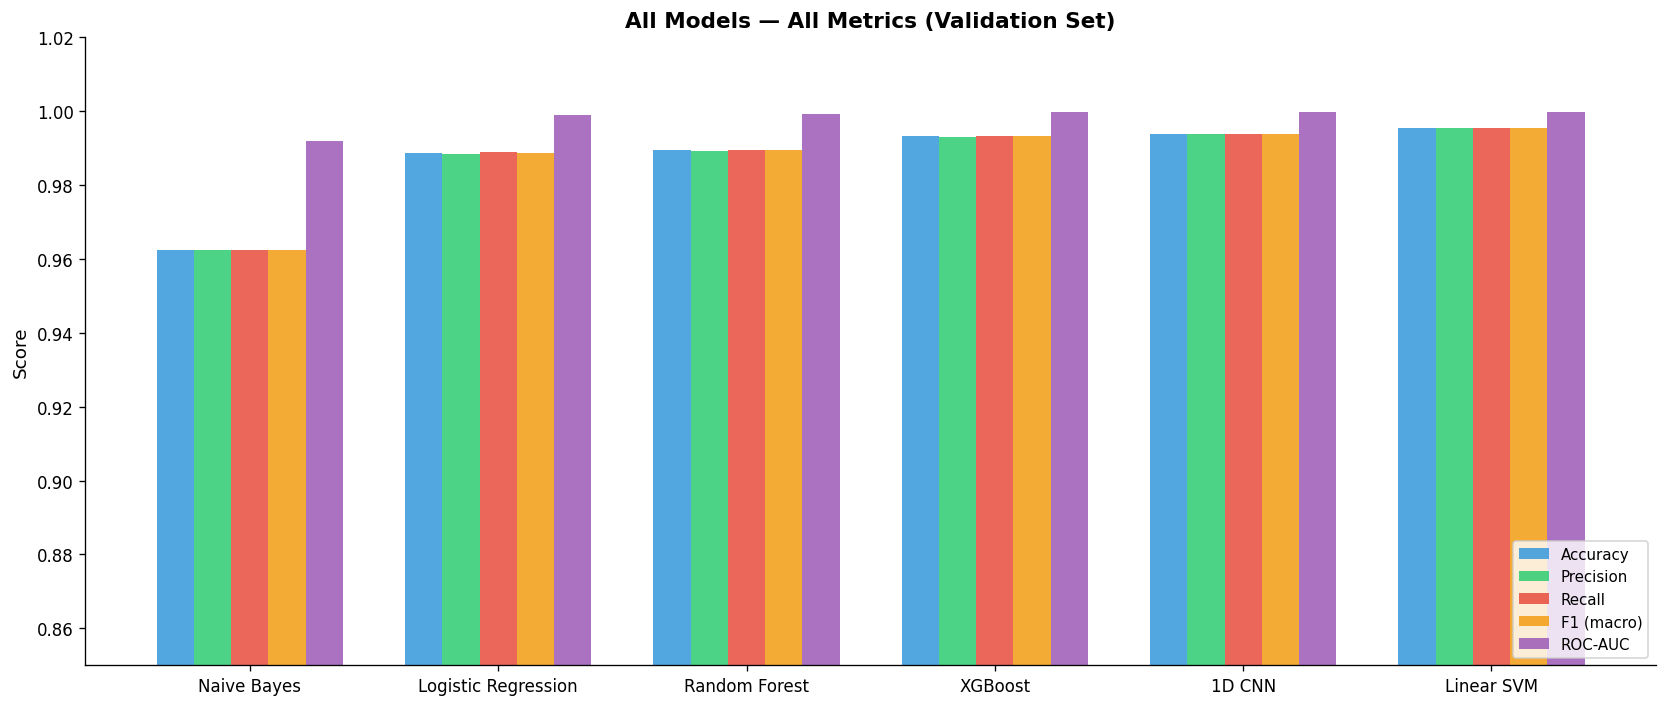

In [19]:
plot_df   = summary_df[['Accuracy','Precision','Recall','F1 (macro)','ROC-AUC']].astype(float)
plot_df   = plot_df.sort_values('F1 (macro)')
x         = np.arange(len(plot_df))
width     = 0.15
colors    = ['#3498db','#2ecc71','#e74c3c','#f39c12','#9b59b6']

fig, ax = plt.subplots(figsize=(14, 6))
for i, (col, color) in enumerate(zip(plot_df.columns, colors)):
    bars = ax.bar(x + i*width, plot_df[col], width, label=col, color=color, alpha=0.85)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(plot_df.index, fontsize=10)
ax.set_ylabel('Score', fontsize=11)
ax.set_ylim(0.85, 1.02)
ax.set_title('All Models — All Metrics (Validation Set)', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
plt.tight_layout()
plt.show()

### 8c. ROC Curves for All Models

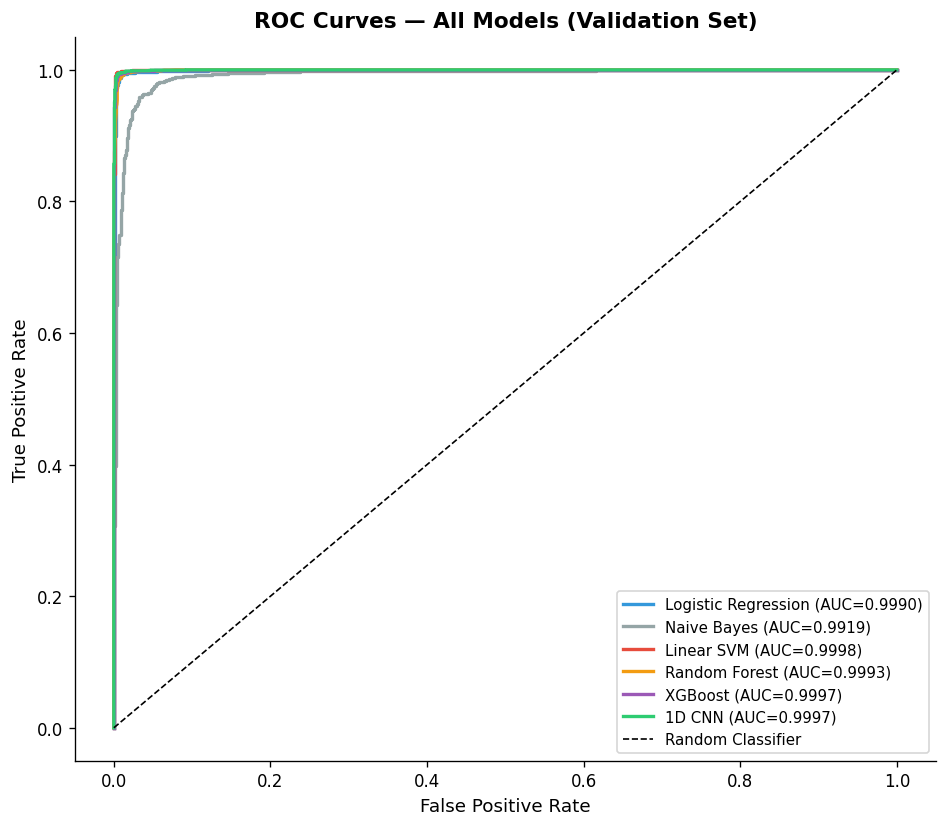

In [20]:
roc_colors = ['#3498db','#95a5a6','#e74c3c','#f39c12','#9b59b6','#2ecc71']

fig, ax = plt.subplots(figsize=(8, 7))
for (name, res), color in zip(val_results.items(), roc_colors):
    fpr, tpr, _ = roc_curve(y_val, res['y_prob'])
    auc = res['ROC-AUC']
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc:.4f})')

ax.plot([0,1],[0,1],'k--', lw=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curves — All Models (Validation Set)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
plt.tight_layout()
plt.show()

### 8d. Confusion Matrices

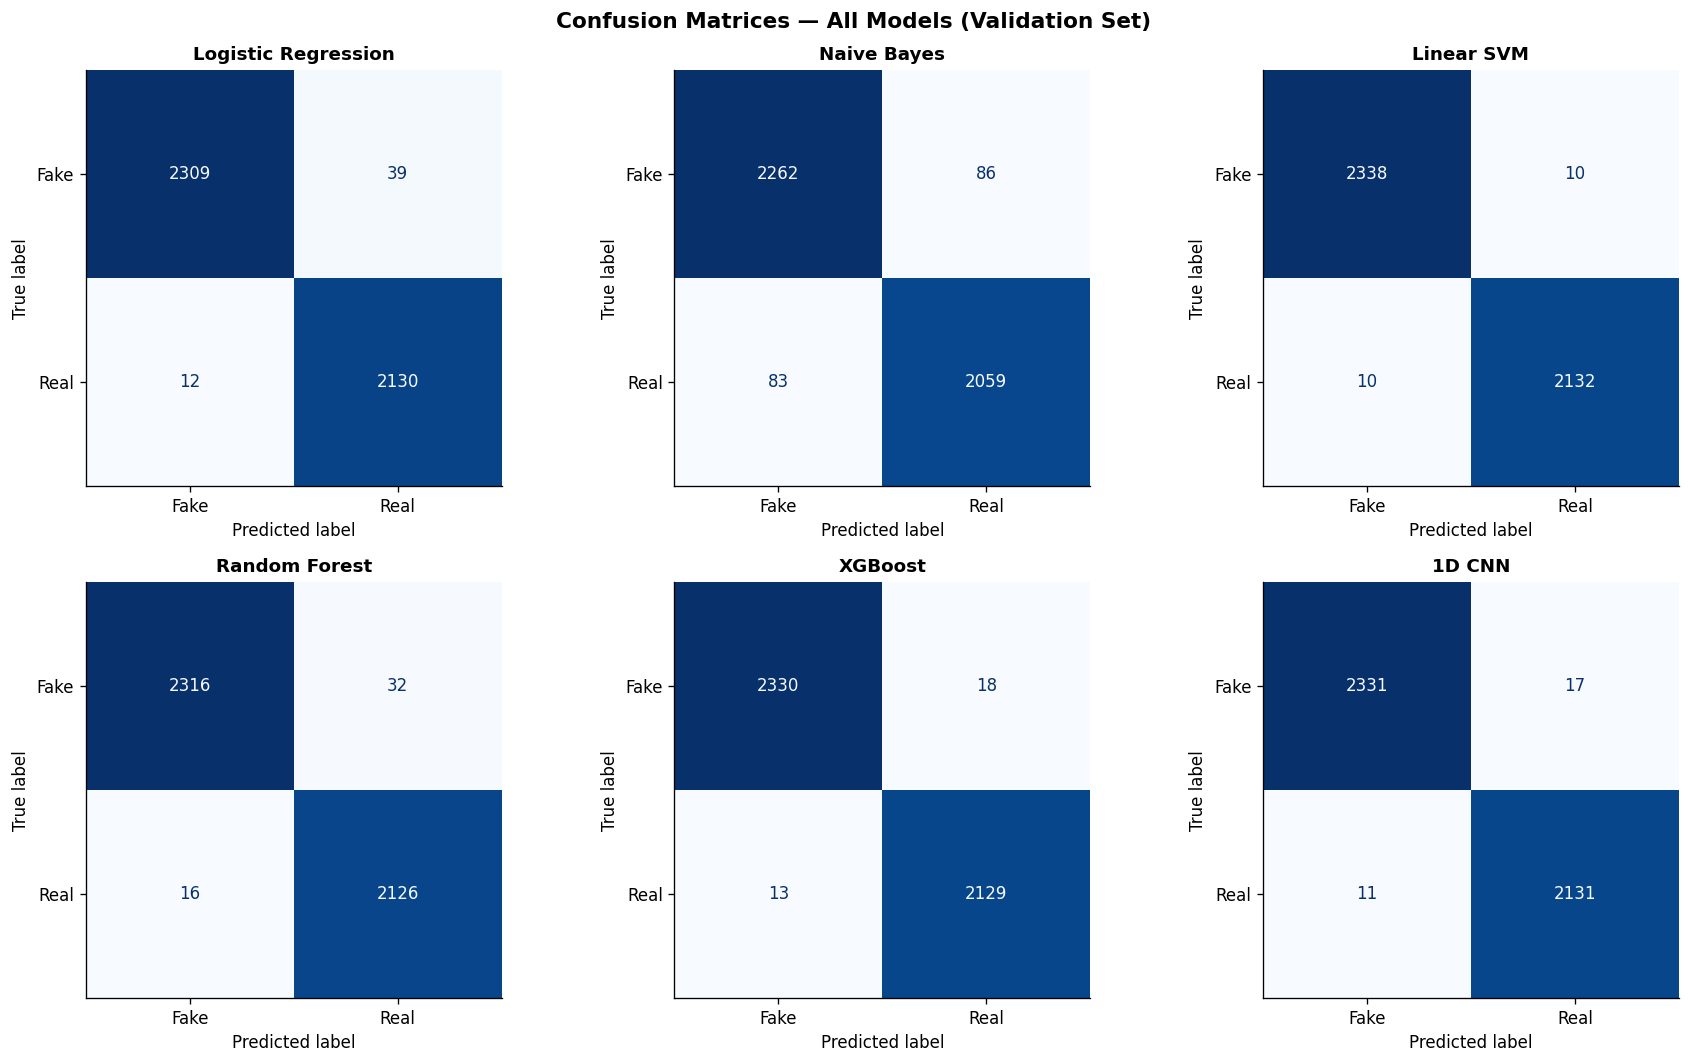

In [21]:
model_names_list = list(val_results.keys())
n = len(model_names_list)
cols = 3
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4.5))
axes = axes.flatten()

for i, name in enumerate(model_names_list):
    cm   = confusion_matrix(y_val, val_results[name]['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fake', 'Real'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(name, fontsize=11, fontweight='bold')

# Hide any unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Confusion Matrices — All Models (Validation Set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 9: Cross-Validation
> **FIX applied:** 5-fold Stratified Cross-Validation added as required by the proposal.

In [22]:
# Combine train + val for CV (test set remains untouched)
import scipy.sparse as sp
X_tv     = sp.vstack([X_train_tfidf, X_val_tfidf])
y_tv     = pd.concat([y_train, y_val]).reset_index(drop=True)

skf      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_models = {
    'Logistic Regression': log_model,
    'Naive Bayes'        : nb_model,
    'Linear SVM'         : svm_model,
    'Random Forest'      : rf_model,
    'XGBoost'            : xgb_model,
}

cv_results = {}
print('Running 5-fold cross-validation (CNN excluded — too slow for CV on CPU)...')
for name, model in cv_models.items():
    t0 = time.time()
    scores = cross_val_score(model, X_tv, y_tv, cv=skf, scoring='f1_macro', n_jobs=-1)
    cv_results[name] = scores
    print(f'  {name:<22} F1: {scores.mean():.4f} ± {scores.std():.4f}  ({time.time()-t0:.1f}s)')

Running 5-fold cross-validation (CNN excluded — too slow for CV on CPU)...
  Logistic Regression    F1: 0.9896 ± 0.0006  (7.1s)
  Naive Bayes            F1: 0.9638 ± 0.0011  (0.8s)
  Linear SVM             F1: 0.9952 ± 0.0007  (17.3s)
  Random Forest          F1: 0.9894 ± 0.0008  (348.1s)
  XGBoost                F1: 0.9923 ± 0.0009  (883.0s)


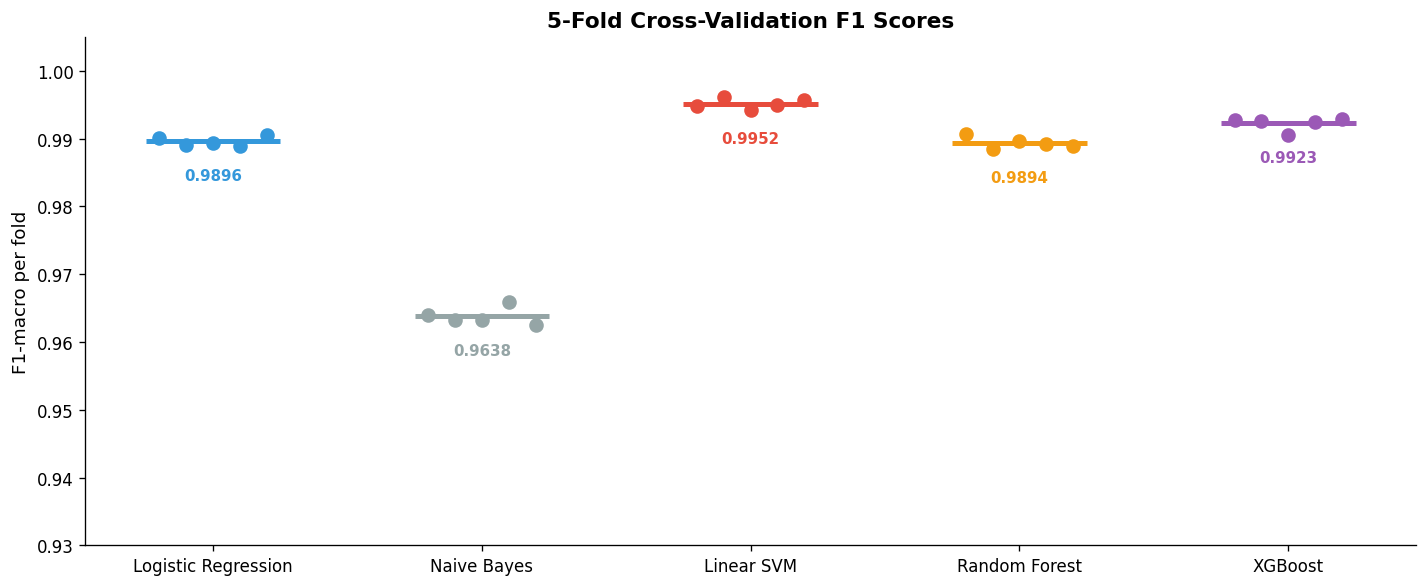

In [23]:
# Plot CV results
fig, ax = plt.subplots(figsize=(12, 5))
cv_colors = ['#3498db','#95a5a6','#e74c3c','#f39c12','#9b59b6']

x_pos = np.arange(len(cv_results))
for xi, (name, scores) in enumerate(cv_results.items()):
    color = cv_colors[xi]
    fold_x = xi + np.linspace(-0.2, 0.2, 5)
    ax.scatter(fold_x, scores, color=color, s=60, zorder=3)
    ax.hlines(scores.mean(), xi-0.25, xi+0.25, color=color, lw=3)
    ax.text(xi, scores.mean() - 0.004, f'{scores.mean():.4f}',
            ha='center', va='top', fontsize=9, fontweight='bold', color=color)

ax.set_xticks(x_pos)
ax.set_xticklabels(list(cv_results.keys()), fontsize=10)
ax.set_ylabel('F1-macro per fold', fontsize=11)
ax.set_title('5-Fold Cross-Validation F1 Scores', fontsize=13, fontweight='bold')
ax.set_ylim(0.93, 1.005)
plt.tight_layout()
plt.show()

---
## Step 10: Ablation Study
> **FIX applied:** Added ablation study to measure the contribution of different feature configurations,
> as required by the proposal.

We test the **best classical model (Linear SVM)** under 4 feature configurations:
1. Title only
2. Text body only
3. Title + Text *(current setup)*
4. Title + Text + Subject (one-hot encoded)

In [24]:
from scipy.sparse import hstack
from sklearn.preprocessing import OneHotEncoder

ablation_results = {}

def run_ablation(X_tr, X_v, name):
    """Fit a fresh Linear SVM on given feature matrix and evaluate on val."""
    base = LinearSVC(random_state=42, dual=False, max_iter=2000)
    clf  = CalibratedClassifierCV(base, cv=3)
    clf.fit(X_tr, y_train)
    res = evaluate(clf, X_v, y_val)
    ablation_results[name] = res
    print(f'  {name:<35} F1={res["F1 (macro)"]:.4f}  AUC={res["ROC-AUC"]:.4f}')

print('Running ablation study (Linear SVM)...\n')

# Config 1: Title only
v1 = TfidfVectorizer(ngram_range=(1,2), max_features=50000, sublinear_tf=True, min_df=3)
run_ablation(v1.fit_transform(news_df.loc[X_train.index, 'title'].fillna('')),
             v1.transform(news_df.loc[X_val.index,   'title'].fillna('')),
             'Title only')

# Config 2: Text body only
v2 = TfidfVectorizer(ngram_range=(1,2), max_features=50000, sublinear_tf=True, min_df=3)
run_ablation(v2.fit_transform(news_df.loc[X_train.index, 'clean_text'].fillna('')),
             v2.transform(news_df.loc[X_val.index,   'clean_text'].fillna('')),
             'Text body only')

# Config 3: Title + Text (baseline, already have these)
ablation_results['Title + Text (baseline)'] = val_results['Linear SVM']
print(f'  {"Title + Text (baseline)":<35} '
      f'F1={val_results["Linear SVM"]["F1 (macro)"]:.4f}  '
      f'AUC={val_results["Linear SVM"]["ROC-AUC"]:.4f}')

# Config 4: Title + Text + Subject (one-hot)
ohe = OneHotEncoder(sparse_output=True, handle_unknown='ignore')
subj_train = ohe.fit_transform(news_df.loc[X_train.index, 'subject'].values.reshape(-1,1))
subj_val   = ohe.transform(news_df.loc[X_val.index,   'subject'].values.reshape(-1,1))
run_ablation(hstack([X_train_tfidf, subj_train]),
             hstack([X_val_tfidf,   subj_val]),
             'Title + Text + Subject')

Running ablation study (Linear SVM)...

  Title only                          F1=0.9670  AUC=0.9950
  Text body only                      F1=0.9955  AUC=0.9998
  Title + Text (baseline)             F1=0.9955  AUC=0.9998
  Title + Text + Subject              F1=1.0000  AUC=1.0000


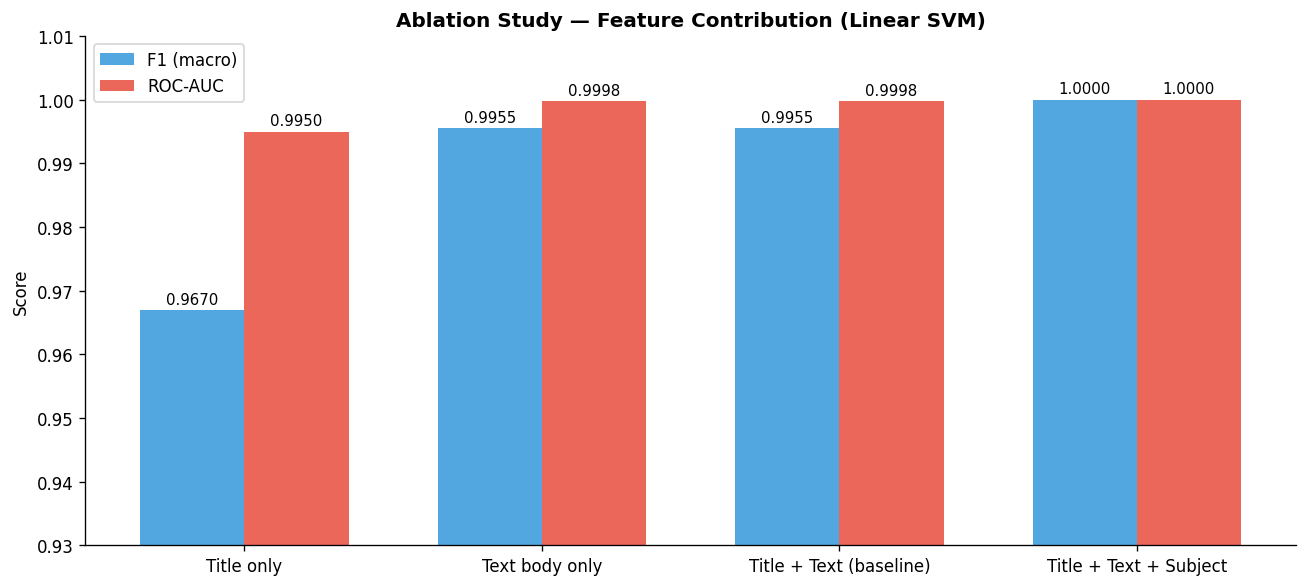

In [25]:
# Plot ablation
abl_names  = list(ablation_results.keys())
abl_f1     = [ablation_results[n]['F1 (macro)'] for n in abl_names]
abl_auc    = [ablation_results[n]['ROC-AUC']    for n in abl_names]

x      = np.arange(len(abl_names))
width  = 0.35
fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - width/2, abl_f1,  width, label='F1 (macro)', color='#3498db', alpha=0.85)
b2 = ax.bar(x + width/2, abl_auc, width, label='ROC-AUC',    color='#e74c3c', alpha=0.85)
ax.bar_label(b1, fmt='%.4f', padding=2, fontsize=9)
ax.bar_label(b2, fmt='%.4f', padding=2, fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(abl_names, fontsize=10)
ax.set_ylim(0.93, 1.01)
ax.set_ylabel('Score')
ax.set_title('Ablation Study — Feature Contribution (Linear SVM)', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

---
## Step 11: Final Test Set Evaluation & Export
### 11a. Select best model, evaluate on held-out test set

In [26]:
# Pick best model by validation F1
best_name  = max(val_results, key=lambda k: val_results[k]['F1 (macro)'])
best_model = model_store[best_name]
print(f'Best model (by val F1): {best_name}')

# Use appropriate test features
X_test_eval = X_test_seq if best_name == '1D CNN' else X_test_tfidf

if best_name == '1D CNN':
    test_prob = best_model.predict(X_test_eval).flatten()
    test_pred = (test_prob > 0.5).astype(int)
    test_res  = {
        'Accuracy'  : accuracy_score(y_test, test_pred),
        'Precision' : precision_score(y_test, test_pred, average='macro'),
        'Recall'    : recall_score(y_test, test_pred, average='macro'),
        'F1 (macro)': f1_score(y_test, test_pred, average='macro'),
        'ROC-AUC'   : roc_auc_score(y_test, test_prob),
        'y_pred'    : test_pred,
        'y_prob'    : test_prob,
    }
else:
    test_res = evaluate(best_model, X_test_tfidf, y_test)
    test_pred = test_res['y_pred']

print(f'\n=== FINAL TEST SET RESULTS ({best_name}) ===')
for k, v in test_res.items():
    if k not in ('y_pred','y_prob'):
        print(f'  {k:<15}: {v:.4f}')

print('\nDetailed Classification Report:')
print(classification_report(y_test, test_pred, target_names=['Fake','Real']))

Best model (by val F1): Linear SVM

=== FINAL TEST SET RESULTS (Linear SVM) ===
  Accuracy       : 0.9971
  Precision      : 0.9971
  Recall         : 0.9971
  F1 (macro)     : 0.9971
  ROC-AUC        : 0.9999

Detailed Classification Report:
              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00      2348
        Real       1.00      1.00      1.00      2142

    accuracy                           1.00      4490
   macro avg       1.00      1.00      1.00      4490
weighted avg       1.00      1.00      1.00      4490



### 11b. Final Confusion Matrix & Prediction Distribution

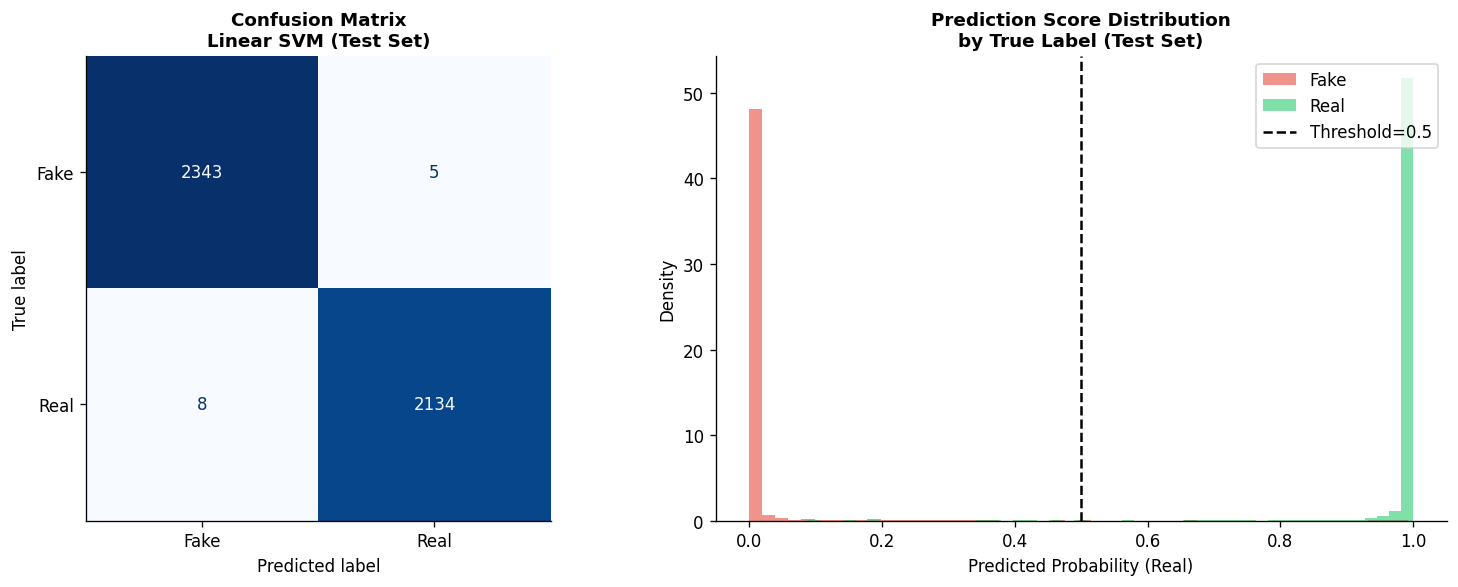

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix
cm   = confusion_matrix(y_test, test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fake', 'Real'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Confusion Matrix\n{best_name} (Test Set)', fontsize=11, fontweight='bold')

# Probability distribution
for label_val, color, name in zip([0,1], PALETTE, ['Fake','Real']):
    mask = (y_test == label_val).values
    axes[1].hist(test_res['y_prob'][mask], bins=50, alpha=0.6,
                 color=color, label=name, density=True)
axes[1].axvline(0.5, color='black', linestyle='--', lw=1.5, label='Threshold=0.5')
axes[1].set_xlabel('Predicted Probability (Real)')
axes[1].set_ylabel('Density')
axes[1].set_title('Prediction Score Distribution\nby True Label (Test Set)', fontsize=11, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

### 11c. Export Model for Flask Deployment

In [28]:
# ── Portable export — works locally AND on Colab ───────────────────────────────
os.makedirs('models', exist_ok=True)

# Always export the best classical (TF-IDF based) model for Flask
# Even if CNN won, we deploy the fastest classical model for CPU inference
classical_models = {k: v for k, v in val_results.items() if k != '1D CNN'}
best_classical   = max(classical_models, key=lambda k: classical_models[k]['F1 (macro)'])
deploy_model     = model_store[best_classical]

joblib.dump(tfidf_vectorizer, 'models/tfidf_vectorizer.pkl')
joblib.dump(deploy_model,     'models/best_model.pkl')

# Save metadata
meta = {
    'deployed_model'  : best_classical,
    'val_f1_macro'    : round(classical_models[best_classical]['F1 (macro)'], 6),
    'val_roc_auc'     : round(classical_models[best_classical]['ROC-AUC'], 6),
    'test_f1_macro'   : round(test_res['F1 (macro)'], 6),
    'test_accuracy'   : round(test_res['Accuracy'], 6),
    'vocab_size'      : len(tfidf_vectorizer.vocabulary_),
    'ngram_range'     : '(1,2)',
    'max_features'    : 50000,
    'train_samples'   : len(X_train),
    'test_samples'    : len(X_test),
}
with open('models/model_metadata.json', 'w') as f:
    json.dump(meta, f, indent=2)

print('=== Files saved to ./models/ ===')
print('  tfidf_vectorizer.pkl  — TF-IDF vectorizer')
print('  best_model.pkl        — Trained classifier')
print('  model_metadata.json   — Run metadata')
print(f'\nDeployed model : {best_classical}')
print(f'Val F1         : {meta["val_f1_macro"]}')
print(f'Test F1        : {meta["test_f1_macro"]}')
print(f'Test Accuracy  : {meta["test_accuracy"]}')

# If running on Colab, also trigger download
try:
    from google.colab import files
    print('\nColab detected — downloading model files...')
    files.download('models/tfidf_vectorizer.pkl')
    files.download('models/best_model.pkl')
except ImportError:
    print('\nLocal environment — files saved to ./models/')

=== Files saved to ./models/ ===
  tfidf_vectorizer.pkl  — TF-IDF vectorizer
  best_model.pkl        — Trained classifier
  model_metadata.json   — Run metadata

Deployed model : Linear SVM
Val F1         : 0.995536
Test F1        : 0.997098
Test Accuracy  : 0.997105

Colab detected — downloading model files...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## Quick Inference Test *(simulates Flask usage)*

In [29]:
def predict_article(title: str, text: str) -> dict:
    """Exactly what the Flask /predict route will call."""
    combined = clean_text(title + ' ' + text)
    vec      = tfidf_vectorizer.transform([combined])
    pred     = deploy_model.predict(vec)[0]
    prob     = deploy_model.predict_proba(vec)[0]
    return {
        'label'      : 'REAL' if pred == 1 else 'FAKE',
        'confidence' : round(float(max(prob)) * 100, 2),
        'fake_prob'  : round(float(prob[0]) * 100, 2),
        'real_prob'  : round(float(prob[1]) * 100, 2),
    }

sample_real = news_df[news_df['label'] == 1].iloc[10]
sample_fake = news_df[news_df['label'] == 0].iloc[10]

r1 = predict_article(sample_real['title'], sample_real['text'])
r2 = predict_article(sample_fake['title'], sample_fake['text'])

print('=== Inference Test ===')
print(f'\nActual: REAL  | Predicted: {r1["label"]}  | Confidence: {r1["confidence"]}%')
print(f'Title : {sample_real["title"][:90]}')
print(f'\nActual: FAKE  | Predicted: {r2["label"]}  | Confidence: {r2["confidence"]}%')
print(f'Title : {sample_fake["title"][:90]}')

=== Inference Test ===

Actual: REAL  | Predicted: REAL  | Confidence: 100.0%
Title : Obama to call for increases in budget for SEC, CFTC: White House

Actual: FAKE  | Predicted: FAKE  | Confidence: 99.99%
Title : FATHER OF BENGHAZI VICTIM TY WOODS SPEAKS UP AGAINST HILLARY: “My son would still be alive
